In [1]:
# Project 9 - Combined Random Forest & Neural Network Classifiers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, recall_score, precision_score, roc_curve
import warnings

sns.set_style("whitegrid")
warnings.filterwarnings('ignore', category=UserWarning)

# Load dataset
df = pd.read_csv("wc1.csv")
X = df.drop('type', axis=1)
y = df['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
print("Dataset wc1.csv loaded successfully.")


Dataset wc1.csv loaded successfully.


In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score
)

In [3]:
# Loading Dataset
df = pd.read_csv("wc1.csv")

print("First 5 rows of the dataset:")
print(df.head())
print("\nColumns in dataset:", df.columns.tolist())

First 5 rows of the dataset:
   inline_count  external_count  onclick_count  onload_count  onchange_count  \
0          21.0            23.0              1         131.0             0.0   
1          13.0            30.0              2           4.0             1.0   
2           0.0             3.0              1           0.0             0.0   
3          21.0            11.0              1          10.0             1.0   
4          10.0             5.0              1           0.0             0.0   

   avg_inline_script_block  avg_external_script_block  avg_onclick_count  \
0                      0.0                 662.062500              30737   
1                      0.0                  55.777778               2951   
2                      0.0                 207.000000                387   
3                      0.0                 104.800000               1505   
4                      0.0                 473.000000               4121   

   avg_onload_count  avg_onchange

In [4]:
# Encoding Target Labels ('type' column)
# Converting string labels into numeric (0 = alexa, 1 = phish)
y = df['type'].map({'alexa': 0, 'phish': 1})

# Defining features
X = df.drop('type', axis=1)

print("Label distribution:\n", y.value_counts())

Label distribution:
 type
0    17562
1     6670
Name: count, dtype: int64


In [5]:
# Splitting Data (33% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 16235, Testing samples: 7997


In [6]:
# Training Random Forest with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix (100 Trees):\n", cm)
print(f"Accuracy (100 Trees): {accuracy_score(y_test, y_pred):.4f}")

Confusion Matrix (100 Trees):
 [[5493  303]
 [ 350 1851]]
Accuracy (100 Trees): 0.9183


AUC (100 Trees): 0.9500


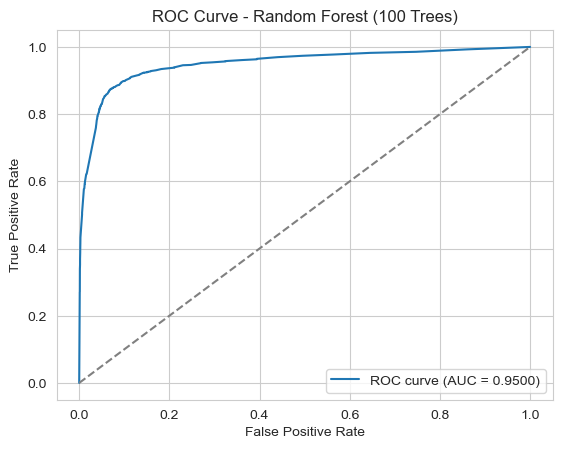

In [7]:
# ROC and AUC (100 Trees)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC (100 Trees): {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (100 Trees)')
plt.legend(loc="lower right")
plt.show()

Top 10 Feature Importances:

avg_onclick_count            0.247075
avg_external_script_block    0.147222
avg_onchange_count           0.141954
inline_count                 0.094060
avg_cyc_complexity           0.086321
external_count               0.086080
library_code_count           0.067195
avg_onload_count             0.056709
onload_count                 0.035078
onclick_count                0.021217
dtype: float64


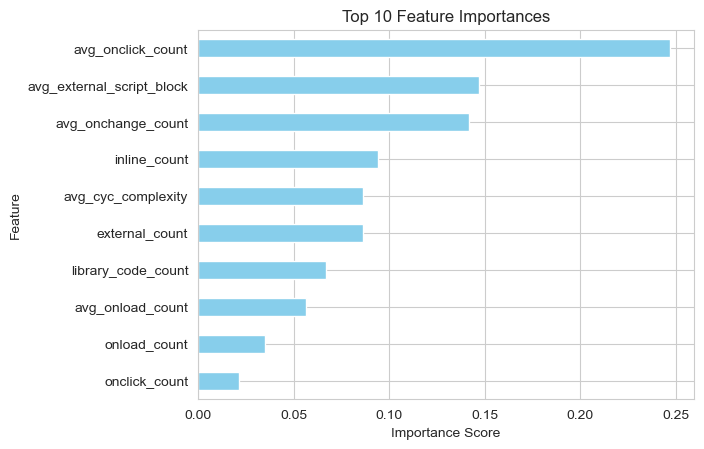

In [8]:
# Displaying Top 10 Important Features
feature_importances = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Top 10 Feature Importances:\n")
print(feature_importances.head(10))

feature_importances.head(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [9]:
# Experimenting with More Trees
tree_counts = [200, 300, 400, 500, 600, 700, 800, 900]

for n_trees in tree_counts:
    rf_model = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf_model.fit(X_train, y_train)
    
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n==== Random Forest ({n_trees} Trees) ====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion Matrix:\n{cm}")


==== Random Forest (200 Trees) ====
Accuracy: 0.9185
Confusion Matrix:
[[5493  303]
 [ 349 1852]]

==== Random Forest (300 Trees) ====
Accuracy: 0.9190
Confusion Matrix:
[[5492  304]
 [ 344 1857]]

==== Random Forest (400 Trees) ====
Accuracy: 0.9187
Confusion Matrix:
[[5495  301]
 [ 349 1852]]

==== Random Forest (500 Trees) ====
Accuracy: 0.9186
Confusion Matrix:
[[5496  300]
 [ 351 1850]]

==== Random Forest (600 Trees) ====
Accuracy: 0.9185
Confusion Matrix:
[[5495  301]
 [ 351 1850]]

==== Random Forest (700 Trees) ====
Accuracy: 0.9186
Confusion Matrix:
[[5494  302]
 [ 349 1852]]

==== Random Forest (800 Trees) ====
Accuracy: 0.9183
Confusion Matrix:
[[5493  303]
 [ 350 1851]]

==== Random Forest (900 Trees) ====
Accuracy: 0.9190
Confusion Matrix:
[[5498  298]
 [ 350 1851]]


In [10]:
# Experimenting with Different Tree Counts for Performance Comparison
tree_counts = [50, 100, 150, 200, 300]

for n_trees in tree_counts:
    rf_model = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf_model.fit(X_train, y_train)
    
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n-- Model with {n_trees} Trees --")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:\n", cm)


-- Model with 50 Trees --
Accuracy: 0.9187
Confusion Matrix:
 [[5489  307]
 [ 343 1858]]

-- Model with 100 Trees --
Accuracy: 0.9183
Confusion Matrix:
 [[5493  303]
 [ 350 1851]]

-- Model with 150 Trees --
Accuracy: 0.9188
Confusion Matrix:
 [[5496  300]
 [ 349 1852]]

-- Model with 200 Trees --
Accuracy: 0.9185
Confusion Matrix:
 [[5493  303]
 [ 349 1852]]

-- Model with 300 Trees --
Accuracy: 0.9190
Confusion Matrix:
 [[5492  304]
 [ 344 1857]]


In [11]:
# Observing Stabilization at Optimal Tree Count (Example: 400 Trees)
optimal_rf_model = RandomForestClassifier(n_estimators=400, random_state=42)
optimal_rf_model.fit(X_train, y_train)

opt_pred = optimal_rf_model.predict(X_test)
opt_acc = accuracy_score(y_test, opt_pred)

print(f"Optimal Model Accuracy (400 Trees): {opt_acc:.4f}")
print("Optimal Confusion Matrix (400 Trees):\n", confusion_matrix(y_test, opt_pred))

Optimal Model Accuracy (400 Trees): 0.9187
Optimal Confusion Matrix (400 Trees):
 [[5495  301]
 [ 349 1852]]


In [12]:
# K-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
fold_accuracies = []

for train_idx, val_idx in kfold.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    rf_model = RandomForestClassifier(n_estimators=400, random_state=42)
    rf_model.fit(X_fold_train, y_fold_train)
    y_fold_pred = rf_model.predict(X_fold_val)
    
    acc = accuracy_score(y_fold_val, y_fold_pred)
    fold_accuracies.append({'model': rf_model, 'accuracy': acc})
    
    print(f"Fold Accuracy: {acc:.4f}")

print(f"\nAverage Cross-Validation Accuracy: {np.mean([f['accuracy'] for f in fold_accuracies]):.4f}")

Fold Accuracy: 0.9236
Fold Accuracy: 0.9119
Fold Accuracy: 0.9187
Fold Accuracy: 0.9181
Fold Accuracy: 0.9224
Fold Accuracy: 0.9298
Fold Accuracy: 0.9119
Fold Accuracy: 0.9181
Fold Accuracy: 0.9316
Fold Accuracy: 0.9298

Average Cross-Validation Accuracy: 0.9216


In [13]:
# Choosing Model with Highest Accuracy
best_rf_model = max(fold_accuracies, key=lambda x: x['accuracy'])['model']

best_pred = best_rf_model.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)

print(f"Best Model Test Accuracy: {best_acc:.4f}")
print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, best_pred))

Best Model Test Accuracy: 0.9145
Best Model Confusion Matrix:
 [[5489  307]
 [ 377 1824]]


ROC AUC Score for Best Model: 0.9506


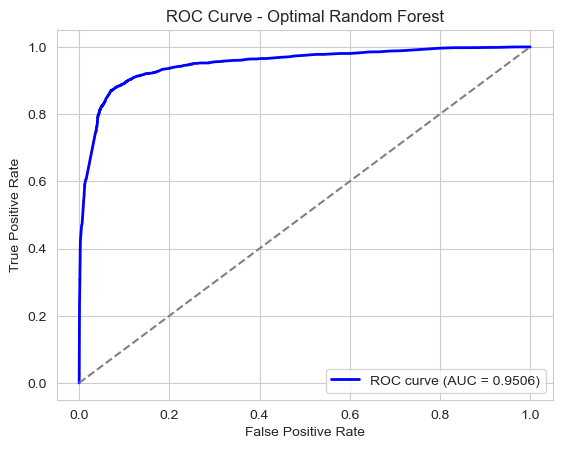

In [14]:
# ROC and AUC for Best Model
best_proba = best_rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
roc_auc = roc_auc_score(y_test, best_proba)

print(f"ROC AUC Score for Best Model: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimal Random Forest')
plt.legend(loc="lower right")
plt.show()

In [15]:
# Project: Machine Learning Part II - Neural Network Classifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler 
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, recall_score, precision_score, roc_curve 
import warnings

sns.set_style("whitegrid")
warnings.filterwarnings('ignore', category=UserWarning) 

# --- Data Loading ---
try:
    df = pd.read_csv('wc1.csv')
    
    # Feature (X) and Target (y) identification
    X = df.drop('type', axis=1)
    y_raw = df['type']

    # Target Encoding: 'phish' (1, Positive Class), 'alexa' (0, Negative Class)
    label_map = {'phish': 1, 'alexa': 0}
    y = y_raw.map(label_map)
    
    print("Data loaded and target encoded successfully.")
    print(f"Dataset shape: {df.shape}")

except Exception as e:
    print(f"ERROR: Could not load data. Ensure 'wc1.csv' is accessible. Error: {e}")

Data loaded and target encoded successfully.
Dataset shape: (24232, 13)


In [16]:
# Data Splitting (Requirement: 33% Testing)
TEST_SIZE = 0.33
RANDOM_STATE = 1 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"--- Data Split (Test Size: {TEST_SIZE*100:.0f}%) ---")
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

# 4. Feature Scaling (MANDATORY FOR MLPClassifier)
# This standardizes the features (mean=0, variance=1)
scaler = StandardScaler()

# Fit scaler only on the training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures have been successfully scaled using StandardScaler.")

--- Data Split (Test Size: 33%) ---
Training Samples: 16235, Testing Samples: 7997

Features have been successfully scaled using StandardScaler.


In [17]:
# --- PART 1: Initial Neural Network Evaluation (max_iter=200) ---
MAX_ITER_INITIAL = 200

print(f"\n--- Initial Model Run (max_iter={MAX_ITER_INITIAL}) ---")

# Use default hidden layers (single layer of size 100) and turn verbose on to capture loss progress
mlp_initial = MLPClassifier(
    random_state=RANDOM_STATE, 
    max_iter=MAX_ITER_INITIAL,
    verbose=True 
)

# Train the model on the scaled data
mlp_initial.fit(X_train_scaled, y_train)

# Output convergence status
print(f"\nModel Stopped at max_iter: {mlp_initial.n_iter_ == MAX_ITER_INITIAL}")

# Initial Confusion Matrix and Metrics
y_pred_initial = mlp_initial.predict(X_test_scaled)
cm_initial = confusion_matrix(y_test, y_pred_initial)

print(f"\nConfusion Matrix (max_iter={MAX_ITER_INITIAL}):\n{cm_initial}")


--- Initial Model Run (max_iter=200) ---
Iteration 1, loss = 0.54014102
Iteration 2, loss = 0.44229841
Iteration 3, loss = 0.41944194
Iteration 4, loss = 0.40397137
Iteration 5, loss = 0.39318570
Iteration 6, loss = 0.38631914
Iteration 7, loss = 0.38174358
Iteration 8, loss = 0.37783702
Iteration 9, loss = 0.37504605
Iteration 10, loss = 0.37292540
Iteration 11, loss = 0.37043158
Iteration 12, loss = 0.36893428
Iteration 13, loss = 0.36739732
Iteration 14, loss = 0.36585197
Iteration 15, loss = 0.36439189
Iteration 16, loss = 0.36351797
Iteration 17, loss = 0.36264598
Iteration 18, loss = 0.36126676
Iteration 19, loss = 0.36037800
Iteration 20, loss = 0.36057134
Iteration 21, loss = 0.35913088
Iteration 22, loss = 0.35861333
Iteration 23, loss = 0.35835641
Iteration 24, loss = 0.35691685
Iteration 25, loss = 0.35643017
Iteration 26, loss = 0.35650101
Iteration 27, loss = 0.35514364
Iteration 28, loss = 0.35422364
Iteration 29, loss = 0.35323950
Iteration 30, loss = 0.35312690
Iterati

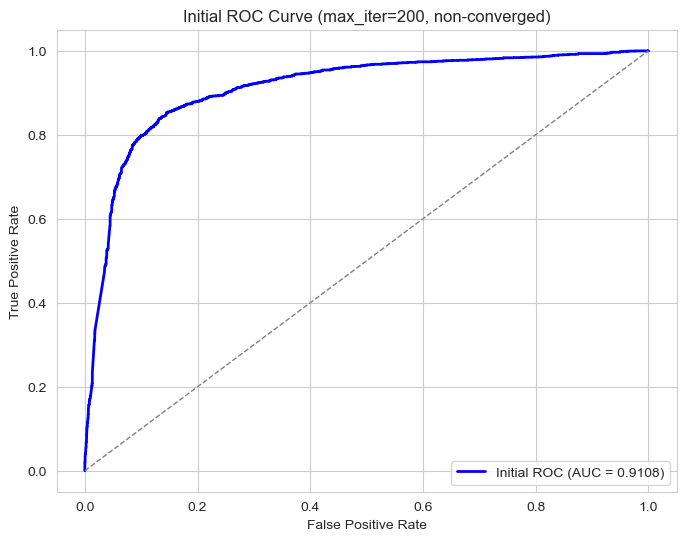

In [18]:
# Plotting ROC curve for the initial (non-converged) model
y_prob_initial = mlp_initial.predict_proba(X_test_scaled)[:, 1]
fpr_initial, tpr_initial, _ = roc_curve(y_test, y_prob_initial)
auc_initial = roc_auc_score(y_test, y_prob_initial)

plt.figure(figsize=(8, 6))
plt.plot(fpr_initial, tpr_initial, color='blue', lw=2, label=f'Initial ROC (AUC = {auc_initial:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Initial ROC Curve (max_iter=200, non-converged)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [19]:
# --- PART 2: Experimentation to Achieve Convergence ---

iteration_settings = [200, 400, 600, 800, 1000]
results = []
MAX_ITER_FINAL = 0

print("\n--- Experimenting with Increased max_iter ---")

for max_i in iteration_settings:
    mlp = MLPClassifier(random_state=RANDOM_STATE, max_iter=max_i)
    
    # Train model
    mlp.fit(X_train_scaled, y_train)
    
    y_pred = mlp.predict(X_test_scaled)
    y_prob = mlp.predict_proba(X_test_scaled)[:, 1]
    
    current_auc = roc_auc_score(y_test, y_prob)
    current_acc = accuracy_score(y_test, y_pred)
    
    converged = mlp.n_iter_ < max_i 
    
    results.append({
        'max_iter': max_i,
        'AUC': current_auc,
        'Accuracy': current_acc,
        'Converged': converged
    })
    
    print(f"max_iter={max_i:4d}: AUC={current_auc:.4f}, Accuracy={current_acc:.4f}, Converged={converged}")
    
    if converged and MAX_ITER_FINAL == 0:
        MAX_ITER_FINAL = max_i

# Set final max_iter based on first converged point, or fallback to highest tested
if MAX_ITER_FINAL == 0:
    MAX_ITER_FINAL = max_i
    print(f"\nModel did not strictly converge up to max_iter={MAX_ITER_FINAL}. Using this value for final training.")
else:
    print(f"\nFinal Convergence Setting Selected: max_iter={MAX_ITER_FINAL}")


--- Experimenting with Increased max_iter ---
max_iter= 200: AUC=0.9108, Accuracy=0.8741, Converged=False
max_iter= 400: AUC=0.9158, Accuracy=0.8796, Converged=False
max_iter= 600: AUC=0.9152, Accuracy=0.8798, Converged=True
max_iter= 800: AUC=0.9152, Accuracy=0.8798, Converged=True
max_iter=1000: AUC=0.9152, Accuracy=0.8798, Converged=True

Final Convergence Setting Selected: max_iter=600


In [20]:
# Final Model Training and Full Evaluation (max_iter = MAX_ITER_FINAL)

print(f"\n--- Final Model Training (max_iter={MAX_ITER_FINAL}) ---")

mlp_final = MLPClassifier(random_state=RANDOM_STATE, max_iter=MAX_ITER_FINAL)
mlp_final.fit(X_train_scaled, y_train)

# Metrics Calculation
y_pred_final = mlp_final.predict(X_test_scaled)
y_prob_final = mlp_final.predict_proba(X_test_scaled)[:, 1]

cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

final_accuracy = accuracy_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_fpr = fp / (fp + tn)
final_auc = roc_auc_score(y_test, y_prob_final)

print(f"\nFinal Test Accuracy: {final_accuracy:.4f}")
print(f"Final Recall (TP Rate): {final_recall:.4f}")
print(f"Final FPR (FP Rate): {final_fpr:.4f}")
print(f"Final AUC Score: {final_auc:.4f}")


# K-FOLD CROSS-VALIDATION (5-Fold)
print("\n--- K-Fold Cross-Validation (k=5) ---")
# Use the full scaled dataset (X_scaled) for CV
X_full_scaled = scaler.fit_transform(X)
cv_scores = cross_val_score(mlp_final, X_full_scaled, y, cv=5, scoring='accuracy')

print(f"CV Accuracy Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.4f} (Standard Deviation: {cv_scores.std():.4f})")


--- Final Model Training (max_iter=600) ---

Final Test Accuracy: 0.8798
Final Recall (TP Rate): 0.7715
Final FPR (FP Rate): 0.0790
Final AUC Score: 0.9152

--- K-Fold Cross-Validation (k=5) ---
CV Accuracy Scores: [0.87724366 0.87414896 0.87226579 0.8708213  0.88031366]
Average CV Accuracy: 0.8750 (Standard Deviation: 0.0034)


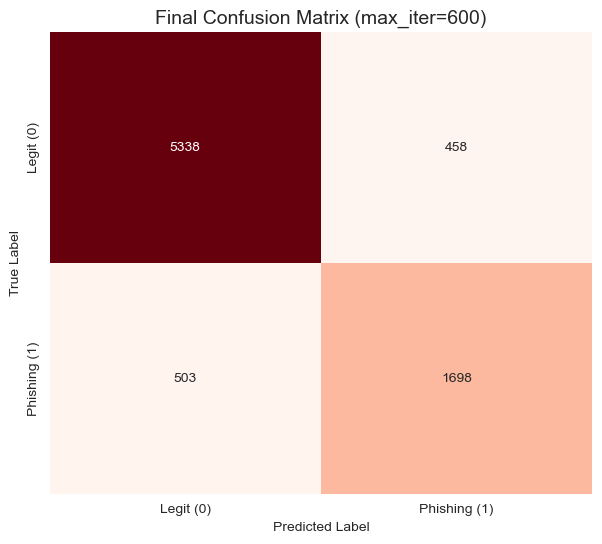

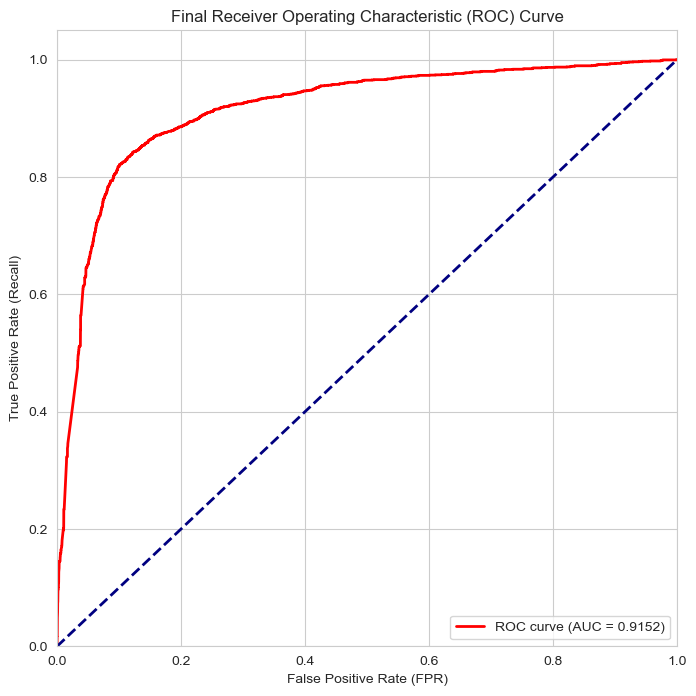

In [21]:
# Plotting the Final Confusion Matrix (Required Visual)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Legit (0)', 'Phishing (1)'],
            yticklabels=['Legit (0)', 'Phishing (1)'])
plt.title(f'Final Confusion Matrix (max_iter={MAX_ITER_FINAL})', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plotting the Final ROC Curve (Required Visual)
fpr_final, tpr_final, _ = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(8, 8))
plt.plot(fpr_final, tpr_final, color='red', lw=2, label=f'ROC curve (AUC = {final_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Final Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()